[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/Strzabala_2025_BEng/paraview.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/Strzabala_2025_BEng/paraview.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/Strzabala_2025_BEng/paraview.ipynb)

Runs a parcel simulation based on Pyrcel documentation setup, and demonstrates export to VTK and visualisation using PyVista

In [1]:
import os, sys
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples', 'PySDM')

In [2]:
import numpy as np
import subprocess
import platform
import pathlib
from PySDM import Formulae
from PySDM.physics import si, in_unit
from PySDM.initialisation.spectra import Lognormal
from PySDM.products import (
    ParcelDisplacement,
    AmbientTemperature,
    AmbientDryAirDensity,
    AmbientRelativeHumidity,
    ParticleSizeSpectrumPerVolume,
    ParticleVolumeVersusRadiusLogarithmSpectrum,
)
from PySDM.exporters import VTKExporterParcel

from PySDM_examples.Pyrcel import Settings, Simulation
import PySDM_examples

In [3]:
settings = Settings(
    dz=10 * si.m,
    n_sd_per_mode=(50, 50),
    aerosol_modes_by_kappa={
        0.54: Lognormal(
            norm_factor=850 / si.cm**3,
            m_mode=15 * si.nm,
            s_geom=1.6,
        ),
        1.2: Lognormal(
            norm_factor=10 / si.cm**3,
            m_mode=850 * si.nm,
            s_geom=1.2,
        ),
    },
    vertical_velocity=1.0 * si.m / si.s,
    initial_pressure=775 * si.mbar,
    initial_temperature=274 * si.K,
    initial_relative_humidity=0.90,
    displacement=1000 * si.m,
    formulae=Formulae(constants={"MAC": 0.3}),
)

dry_radius_bin_edges = np.logspace(
    np.log10(1e-3 * si.um), np.log10(5e0 * si.um), 33, endpoint=False
)

simulation = Simulation(
    settings,
    products=(
        ParcelDisplacement(name="z"),
        AmbientRelativeHumidity(name="S_max_percent", unit="%", var="RH"),
        AmbientDryAirDensity(),
    ),
    mass_of_dry_air = 66666 * si.kg,
    additional_attributes = ("radius",)
)

In [4]:
output = simulation.run()

In [5]:
e = VTKExporterParcel(n_sd=simulation.particulator.n_sd, output=output, mass_of_dry_air=simulation.particulator.environment.mass_of_dry_air)
for step in settings.output_steps:
    e.export_products(step, simulation)
    e.export_attributes(step, simulation)
e.write_pvd()

### PyVista

In [6]:
import pyvista as pv
import vtk
import numpy as np
from matplotlib import colors

pv.set_jupyter_backend('static')
readers = {
    'prod': pv.get_reader("./output/sd_products.pvd"),
    'attr': pv.get_reader("./output/sd_attributes.pvd")
}


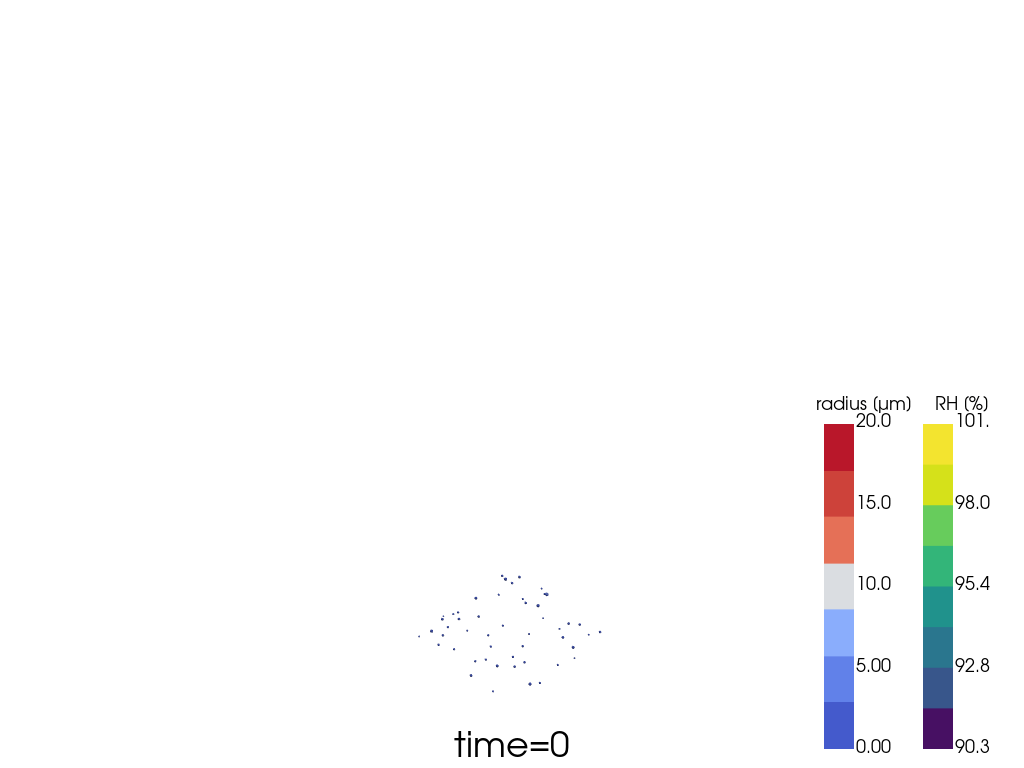

HTML(value="<a href='./parcel_animation.gif' target='_blank'>./parcel_animation.gif</a><br>")

In [7]:
from open_atmos_jupyter_utils import TemporaryFile
gif_file = TemporaryFile(filename="output/parcel_animation.gif")

readers['prod'].set_active_time_point(readers['prod'].number_time_points -1)
data = readers['prod'].read()[0]
prod_min, prod_max = data.get_data_range('RH')

mesh_actor = None
attr_actor = None
title_actor = None

def attr_log10_range(attr):
    log_value_min, log_value_max = float('inf'), float('-inf')
    for i in range(readers['attr'].number_time_points):
        readers['attr'].set_active_time_point(i)
        value = readers['attr'].read()[0].point_data[attr]
        log_value = np.log10(value)
        log_value_min = min(log_value_min, log_value.min())
        log_value_max = max(log_value_max, log_value.max())
    return log_value_min, log_value_max

log_vol_min, log_vol_max = attr_log10_range("volume")

pl = pv.Plotter(notebook=False, off_screen=True)
pl.open_gif(gif_file.basename, subrectangles=True)

for i in range(readers['prod'].number_time_points):
    for reader in readers.values():
        reader.set_active_time_point(i)

    if mesh_actor is not None:
        pl.remove_actor(mesh_actor)

    if attr_actor is not None:
        pl.remove_actor(attr_actor)

    if title_actor is not None:
        pl.remove_actor(title_actor)

    title_actor = pl.add_text(
        "time=" + str(i),
        position='lower_edge',
        font_size=14,
        color='black'
    )

    attr_data = readers['attr'].read()[0]
    radius = attr_data.point_data['radius'].copy()

    attr_data.point_data['vol_display'] = in_unit(radius, si.um)

    glyphed = attr_data.glyph(
        scale='vol_display',
        geom=pv.Sphere(radius=1.0),
        orient=False,
    )

    glyphed = attr_data.glyph(
        scale='vol_display',
        geom=pv.Sphere(radius=1.0),
        orient=False,
    )

    mesh_actor = pl.add_mesh(
        readers['prod'].read()[0],
        scalars='RH',
        cmap = colors.ListedColormap(['#471063', '#38568B', '#2A768E', '#20928C', '#33B579', '#67CC5C', '#D5E11A', '#F3E42F']),
        clim=[prod_min, prod_max],
        scalar_bar_args={"title": "RH [%]", "vertical": True},
        opacity = 0.50,
        remove_existing_actor = True,
        nan_color = "white",
        nan_opacity = 0.0
    )

    attr_actor = pl.add_mesh(
        glyphed,
        scalars='vol_display',
        #cmap='coolwarm',
        cmap = colors.ListedColormap(['#445ACC', '#6181E9','#8AADFC', '#DADDE1', '#E57057', '#CD423A', '#B9172A']),
        clim=[0, 20],
        scalar_bar_args={"title": "radius [μm]", "vertical": True},
    )

    pl.render()
    pl.write_frame()

pl.close()

from open_atmos_jupyter_utils import show_gif
show_gif(gif_file)

In [8]:
# Czas
# Wysokość
# graniastosłup się rozszerza
# mniejszy rozmiar klatek -> zeby zmiescic sie w limicie 2MB